Converged at Epoch: 966
Slope (theta0): 85.14991903528272
Intercept (theta1): 140.7392874410844


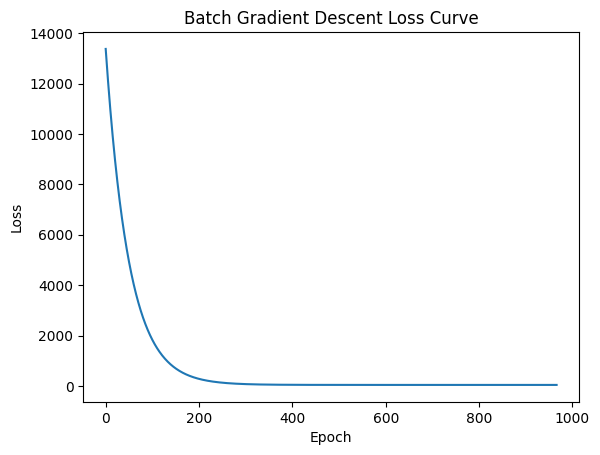

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("C:/Users/sriji/Downloads/Synthetic (2).csv")
df.drop(columns=["Unnamed: 0"],inplace=True)

X=df.iloc[:,0].values
y=df.iloc[:,1].values
X=(X-X.mean())/X.std()


class LinearRegressionBGD:

    def __init__(self,learning_rate=0.01,epochs=10000,tol=1e-6):

        self.lr=learning_rate
        self.epochs=epochs
        self.tol=tol

        self.theta0=np.random.randn()
        self.theta1=np.random.randn()

        self.losses=[]

    def predict(self,X):

        return self.theta0*X+self.theta1

    def mse(self,y_true,y_pred):

        return np.mean((y_true-y_pred)**2)

    def fit(self,X,y):

        m=len(X)

        self.losses=[]

        for epoch in range(self.epochs):

            y_hat=self.predict(X)

            error=y_hat-y

            loss=0.5*np.mean(error**2)

            dt0=(1/m)*np.sum(X*error)
            dt1=(1/m)*np.sum(error)

            self.theta0=self.theta0-self.lr*dt0
            self.theta1=self.theta1-self.lr*dt1

            self.losses.append(loss)

            if epoch>0:
                if abs(self.losses[-1]-self.losses[-2])<self.tol:
                    print("Converged at Epoch:",epoch)
                    break

        return self


model=LinearRegressionBGD(learning_rate=0.01,epochs=10000,tol=1e-6)

model.fit(X,y)

print("Slope (theta0):",model.theta0)
print("Intercept (theta1):",model.theta1)

plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Batch Gradient Descent Loss Curve")
plt.show()


Slope (theta0): 85.14344246415016
Intercept (theta1): 140.79767608925914


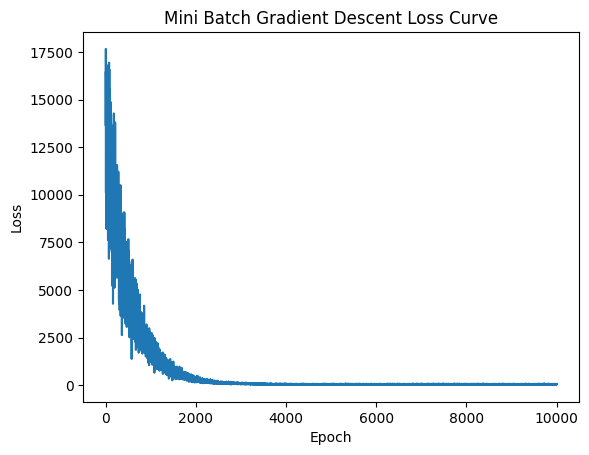

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("C:/Users/sriji/Downloads/Synthetic (2).csv")
df.drop(columns=["Unnamed: 0"],inplace=True)

X=df.iloc[:,0].values
y=df.iloc[:,1].values

X=(X-X.mean())/X.std()


class LinearRegressionMBGD:

    def __init__(self,learning_rate=0.001,epochs=10000,tol=1e-6,batch_size=32):

        self.lr=learning_rate
        self.epochs=epochs
        self.tol=tol
        self.batch_size=batch_size

        self.theta0=np.random.randn()
        self.theta1=np.random.randn()

        self.losses=[]

    def predict(self,X):

        return self.theta0*X+self.theta1

    def mse(self,y_true,y_pred):

        return np.mean((y_true-y_pred)**2)

    def fit(self,X,y):

        m=len(X)

        if self.batch_size>m:
            self.batch_size=m

        self.losses=[]

        for epoch in range(self.epochs):

            idx=np.random.choice(m,self.batch_size,replace=False)

            X_batch=X[idx]
            y_batch=y[idx]

            y_hat=self.predict(X_batch)

            error=y_hat-y_batch

            loss=0.5*np.mean(error**2)

            dt0=(1/self.batch_size)*np.sum(X_batch*error)
            dt1=(1/self.batch_size)*np.sum(error)

            self.theta0=self.theta0-self.lr*dt0
            self.theta1=self.theta1-self.lr*dt1

            self.losses.append(loss)

            if np.isnan(loss):
                print("NaN encountered at epoch:",epoch)
                break

            if epoch>0:
                if abs(self.losses[-1]-self.losses[-2])<self.tol:
                    print("Converged at Epoch:",epoch)
                    break

        return self


model=LinearRegressionMBGD(learning_rate=0.001,
    epochs=10000,
    tol=1e-6,
    batch_size=16
)

model.fit(X,y)

print("Slope (theta0):",model.theta0)
print("Intercept (theta1):",model.theta1)


plt.plot(model.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mini Batch Gradient Descent Loss Curve")
plt.show()

Slope (theta0): 84.73208532511426
Intercept (theta1): 140.91974559779877


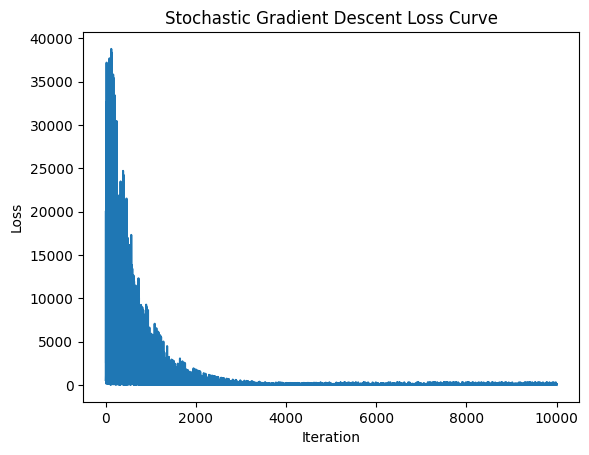

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("C:/Users/sriji/Downloads/Synthetic (2).csv")
df.drop(columns=["Unnamed: 0"],inplace=True)

X=df.iloc[:,0].values
y=df.iloc[:,1].values


X=(X-X.mean())/X.std()


class LinearRegressionSGD:

    def __init__(self,learning_rate=0.001,epochs=10000,tol=1e-6):

        self.lr=learning_rate
        self.epochs=epochs
        self.tol=tol

        self.theta0=np.random.randn()
        self.theta1=np.random.randn()

        self.losses=[]

    def predict(self,X):

        return self.theta0*X+self.theta1

    def mse(self,y_true,y_pred):

        return np.mean((y_true-y_pred)**2)

    def fit(self,X,y):

        m=len(X)

        self.losses=[]

        for epoch in range(self.epochs):

            i=np.random.randint(m)

            x_i=X[i]
            y_i=y[i]

            y_hat=self.theta0*x_i+self.theta1

            error=y_hat-y_i

            loss=0.5*(error**2)

            dt0=x_i*error
            dt1=error

            self.theta0=self.theta0-self.lr*dt0
            self.theta1=self.theta1-self.lr*dt1

            self.losses.append(loss)

            if np.isnan(loss):
                print("NaN encountered at epoch:",epoch)
                break

            if epoch>0:
                if abs(self.losses[-1]-self.losses[-2])<self.tol:
                    print("Converged at Epoch:",epoch)
                    break

        return self


model=LinearRegressionSGD(learning_rate=0.001,epochs=10000,tol=1e-6)

model.fit(X,y)


print("Slope (theta0):",model.theta0)
print("Intercept (theta1):",model.theta1)

plt.plot(model.losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Stochastic Gradient Descent Loss Curve")
plt.show()